In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from flash_ansr import FlashANSRDataset, get_path

In [2]:
class Learner(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: list[int], output_size: int):
        super(Learner, self).__init__()
        layers = []
        in_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_size, hidden_size))
            layers.append(nn.GELU())
            in_size = hidden_size
        layers.append(nn.Linear(in_size, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
def train_learner(x: torch.Tensor, y: torch.Tensor, learner: Learner, epochs: int = 1000, optimizer_kwargs: dict = {}, verbose: bool = False) -> tuple[Learner, list[float]]:
    criterion = nn.MSELoss()
    optimizer = optim.Adam(learner.parameters(), **optimizer_kwargs)

    history = []

    for epoch in tqdm(range(epochs), disable=not verbose):
        optimizer.zero_grad()
        outputs = learner(x)
        assert outputs.shape == y.shape, f"Expected output shape {y.shape=}, got {outputs.shape=}"
        loss: torch.Tensor = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        history.append(loss.item())

    return learner, history

In [4]:
dataset = FlashANSRDataset.from_config(get_path('configs', 'v23.0-120M', 'dataset_train.yaml'))

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 21688.04it/s]


In [5]:
histories = []
for batch in dataset.iterate(100, batch_size=1, verbose=True):
    _, history = train_learner(batch['x_tensors'][0], batch['y_tensors'][0], Learner(input_size=17, hidden_sizes=[128, 128], output_size=1), epochs=1000, optimizer_kwargs={'lr': 0.001, 'weight_decay': 1e-3})
    histories.append({
        'skeleton': batch['skeleton'][0],
        'history': history,
        'n_support': batch['n_support'][0],
        'constants': batch['constants'][0],
    })

Generating Batches: 100%|██████████| 100/100 [01:58<00:00,  1.18s/it]


In [6]:
for i, history in enumerate(histories):
    histories[i]['final_loss'] = history['history'][-1]

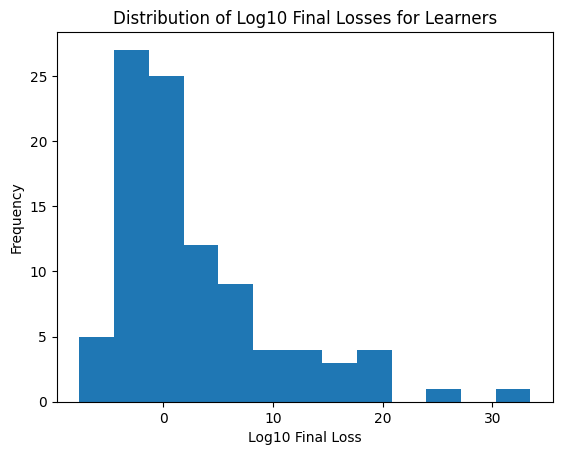

In [ ]:
fig, ax = plt.subplots()
final_losses = np.array([h['final_loss'] for h in histories])
final_losses = final_losses[np.isfinite(final_losses)]
ax.hist(np.log10(final_losses), bins='auto')
ax.set_xlabel('Log10 Final Loss')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Log10 Final Losses for Learners')

In [ ]:
class Functions:
    @staticmethod
    def f1(x):
        return x[:, 0]
    
    @staticmethod
    def f2(x):
        return x[:, 0]**2
    
    @staticmethod
    def f3(x, a):
        return torch.sin(a * x[:, 0]) * x[:, 0]
    
    @staticmethod
    def f4(x, a):
        return torch.sin(a * x[:, 0]) * x[:, 1]

In [128]:
x = torch.tensor(np.random.uniform(-1, 1, (256, 2)), dtype=torch.float32)
print(x.shape)
y = Functions.f4(x, 5.0)
print(y.shape)

# plt.scatter(x.numpy(), y.numpy())

torch.Size([256, 2])
torch.Size([256])


In [129]:
learner, history = train_learner(x, y, Learner(input_size=2, hidden_sizes=[128, 128], output_size=1), epochs=1000, optimizer_kwargs={'lr': 0.001, 'weight_decay': 1e-3})

100%|██████████| 1000/1000 [00:00<00:00, 1238.92it/s]


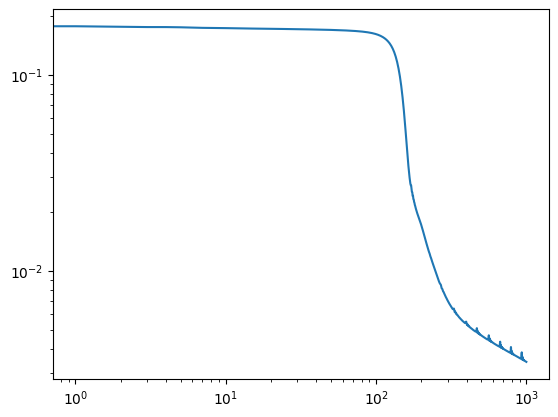

In [130]:
fig, ax = plt.subplots()

ax.plot(history)

ax.set_xscale('log')
ax.set_yscale('log')

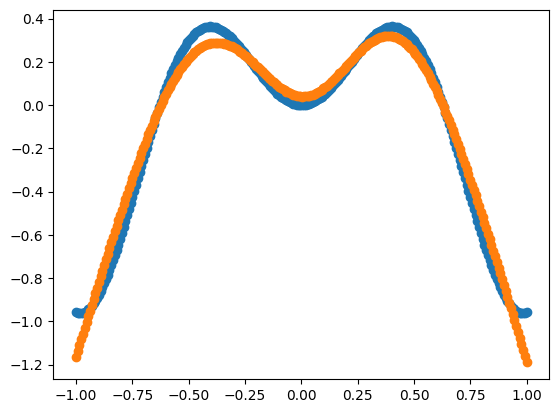

In [126]:
fig, ax = plt.subplots()

x_linspace = torch.linspace(-1, 1, 256).unsqueeze(1)
y_true = Functions.f3(x_linspace, 5.0)
y_pred = learner(x_linspace)

ax.scatter(x_linspace.numpy(), y_true.numpy(), label='True')
ax.scatter(x_linspace.numpy(), y_pred.detach().numpy(), label='Predicted')